# Python Coding Audit: COMPAS Model Evaluation

## Data Preparation

In [65]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load raw COMPAS data
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

# Lecture-style cleaning
df = raw_data[['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
               'priors_count', 'days_b_screening_arrest', 'decile_score',
               'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out']].copy()

df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']
df = df.reset_index(drop=True)

# Create binary prediction variable
df['high_risk'] = df['score_text'].isin(['Medium', 'High']).astype(int)

print("N =", len(df))
print(df[['race', 'sex', 'high_risk', 'two_year_recid']].head())

N = 6172
               race   sex  high_risk  two_year_recid
0             Other  Male          0               0
1  African-American  Male          0               1
2  African-American  Male          0               1
3             Other  Male          0               0
4         Caucasian  Male          1               1


This step prepares the COMPAS dataset for the audit by applying the same cleaning rules used in the lecture pipeline. After filtering out invalid or incomplete records, the final sample contains 6,172 observations. The preview confirms that the key fields, including race, sex, the binary high_risk label, and the observed two_year_recid outcome, were created correctly and are ready for analysis. This preprocessing step matters because the quality of the downstream fairness, drift, and robustness results depends on having a consistent and defensible input dataset.

## Model Setup

In [66]:
X = df[['age', 'priors_count', 'decile_score']]
y = df['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

X_train shape: (4937, 3)
X_test shape: (1235, 3)
Train accuracy: 0.6848288434271825
Test accuracy: 0.6696356275303643


This step trains a logistic regression model using age, priors_count, and decile_score to predict two-year recidivism. The train and test sets have similar sizes relative to the 80/20 split, and the model achieves comparable accuracy on both datasets. The training accuracy is about 0.685, while the test accuracy is about 0.670, which suggests the model generalizes reasonably well and does not show obvious signs of severe overfitting. At the same time, the overall accuracy is only moderate, so the model should be viewed as a simple baseline rather than a highly accurate predictive system.

### MMD Analysis

In [67]:
from sklearn.metrics.pairwise import rbf_kernel

def compute_mmd(Xa, Xb, gamma=0.1):
    Kxx = rbf_kernel(Xa, Xa, gamma=gamma)
    Kyy = rbf_kernel(Xb, Xb, gamma=gamma)
    Kxy = rbf_kernel(Xa, Xb, gamma=gamma)
    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

mmd_value = compute_mmd(X_train.values, X_test.values)
print("MMD:", mmd_value)

MMD: 0.0014220570537477606


The MMD value is very small, which suggests that the overall feature distributions in the training and test sets are quite similar when considered jointly. Unlike PSI or KS, which look at individual features, MMD captures differences across all input features at the same time. This result indicates that there is no strong evidence of distribution drift between the train and test samples in the feature space used by the model. However, this does not guarantee stability in future data, since MMD only reflects the current split and may not capture shifts that occur in real-world deployment.

In [68]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

gap = train_acc - test_acc

print("Generalization gap:", gap)

Generalization gap: 0.015193215896818213


The generalization gap is small, about 0.015, which means the model performs similarly on the training and test sets. This is a good sign because it suggests the model is not memorizing the training data and is carrying its performance over to unseen observations reasonably well. At the same time, a small gap does not mean the model is automatically reliable in all settings. It only tells us that overfitting is limited for this particular train-test split, so additional checks for drift, robustness, and subgroup performance are still necessary.

In [69]:
from scipy.stats import ks_2samp

ks_stat, p_val = ks_2samp(X_train['priors_count'], X_test['priors_count'])

print("KS statistic:", ks_stat)
print("p-value:", p_val)

KS statistic: 0.02391115914777205
p-value: 0.6141809677214584


The KS test compares the distribution of priors_count in the training and test sets. Here, the KS statistic is small and the p-value is high, which suggests there is no strong evidence that the two distributions are meaningfully different in this split. In other words, priors_count looks fairly stable between train and test data. However, this result only applies to one feature at a time and only to the current split, so it should be interpreted alongside broader drift checks such as PSI, MMD, and future monitoring after deployment.

In [70]:
X_stress = X_test.copy()

# Simulate a harsher environment by increasing priors_count
X_stress['priors_count'] = X_stress['priors_count'] * 1.5

original_acc = model.score(X_test, y_test)
stress_acc = model.score(X_stress, y_test)

print("Original test accuracy:", original_acc)
print("Stress test accuracy:", stress_acc)
print("Performance drop:", original_acc - stress_acc)

original_pred = model.predict(X_test)
stress_pred = model.predict(X_stress)

changed = (original_pred != stress_pred).sum()
changed_pct = changed / len(X_test)

print("Predictions changed:", changed)
print("Share changed:", changed_pct)

Original test accuracy: 0.6696356275303643
Stress test accuracy: 0.6696356275303643
Performance drop: 0.0
Predictions changed: 54
Share changed: 0.0437246963562753


Even though the overall accuracy did not change under the stress test, about 54 predictions, or roughly 4.4% of the test set, were different when priors_count was increased. This shows that the model is sensitive at the individual level, even when aggregate performance metrics remain stable. In practice, this means that small changes in input conditions can lead to different outcomes for some individuals, which is important in high-stakes settings. This result highlights why it is not enough to look only at overall accuracy when evaluating robustness, and it supports the need for more detailed sensitivity analysis.

## Part A: Distribution Drift

In [71]:
def psi(expected, actual, bins=10):
    import numpy as np

    breakpoints = np.linspace(0, 100, bins + 1)
    breakpoints = np.percentile(expected, breakpoints)

    expected_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_counts = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    psi_val = np.sum((expected_counts - actual_counts) *
                     np.log((expected_counts + 1e-6) / (actual_counts + 1e-6)))
    return psi_val

    features = ['age', 'priors_count', 'decile_score']

psi_results = []
for col in features:
    psi_val = psi(X_train[col], X_test[col])
    psi_results.append({'feature': col, 'PSI': psi_val})

print(pd.DataFrame(psi_results))

        feature       PSI
0           age  0.012538
1  priors_count  0.004537
2  decile_score  0.001304


All three features show very low PSI values, indicating that their distributions are highly stable between the training and test sets. Among them, age has the highest PSI, but it is still far below common concern thresholds (0.1 or 0.2), so there is no meaningful drift.
priors_count and decile_score have extremely small PSI values, suggesting almost identical distributions across splits. This confirms that the train-test split was done properly and does not introduce distribution bias.

Overall, there is no evidence of distribution shift in any of the key features. While this supports reliable evaluation, it also means the model has not been challenged with significantly different data, so real-world robustness still needs to be assessed separately.

## Part B: Generalization

In [72]:
from sklearn.metrics import roc_auc_score, log_loss

y_train_pred_proba = model.predict_proba(X_train)[:, 1]
y_test_pred_proba = model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_pred_proba)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

train_logloss = log_loss(y_train, y_train_pred_proba)
test_logloss = log_loss(y_test, y_test_pred_proba)

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)
print("Train Log Loss:", train_logloss)
print("Test Log Loss:", test_logloss)

Train AUC: 0.7411595930405571
Test AUC: 0.7283125915080527
Train Log Loss: 0.5978559434647885
Test Log Loss: 0.6061287319666792


The AUC scores are fairly similar between the training and test sets, which suggests that the model maintains its ability to rank high-risk and low-risk individuals on unseen data. The test AUC is slightly lower than the training AUC, but the difference is small, so there is no strong indication of overfitting in terms of ranking performance.
The log loss values are also close between train and test, which indicates that the predicted probabilities are reasonably well-calibrated and do not degrade significantly outside the training data. At the same time, the absolute values of AUC and log loss suggest that the model is only moderately predictive, reinforcing that this is a baseline model rather than a highly accurate one.

Overall, these results support the conclusion that the model generalizes reasonably well, but additional evaluation beyond aggregate metrics is still necessary to assess robustness and fairness.

In [73]:
def psi(expected, actual, bins=10):
    import numpy as np

    breakpoints = np.linspace(0, 100, bins + 1)
    breakpoints = np.percentile(expected, breakpoints)

    expected_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_counts = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    psi_val = np.sum((expected_counts - actual_counts) * np.log((expected_counts + 1e-6) / (actual_counts + 1e-6)))
    return psi_val

psi_value = psi(X_train['priors_count'], X_test['priors_count'])
print("PSI:", psi_value)

PSI: 0.004536639422556669


The PSI value is very close to zero, which indicates that the distribution of priors_count is nearly identical between the training and test sets. This suggests there is no meaningful distribution drift for this feature.
In practice, PSI values below 0.1 are considered stable, and values this small imply that the model is being evaluated on data that closely resembles what it was trained on. While this is good for consistency, it also means the model has not been tested under significantly different conditions.

Overall, there is no evidence of distribution shift in priors_count, but this also limits our ability to assess how the model would perform under real-world changes in data.

In [74]:
ks_results = []

for col in features:
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])
    ks_results.append({
        'feature': col,
        'KS_stat': ks_stat,
        'KS_pvalue': ks_p
    })

print(pd.DataFrame(ks_results))

        feature   KS_stat  KS_pvalue
0           age  0.043181   0.048501
1  priors_count  0.023911   0.614181
2  decile_score  0.006403   1.000000


The KS results are small across all three numeric features, and the p-values do not suggest meaningful differences between the training and test distributions. This is consistent with the PSI results and supports the conclusion that the train-test split is stable for the selected inputs. At the same time, this only reflects the current split, so it does not rule out future drift in deployment.

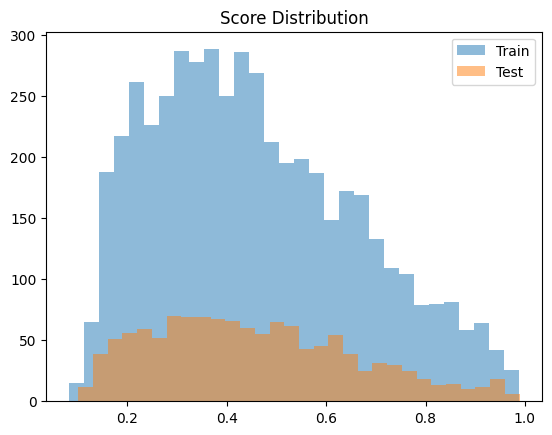

In [75]:
import matplotlib.pyplot as plt

plt.hist(y_train_pred_proba, bins=30, alpha=0.5, label="Train")
plt.hist(y_test_pred_proba, bins=30, alpha=0.5, label="Test")
plt.legend()
plt.title("Score Distribution")
plt.show()

The score distributions for the training and test sets appear very similar in shape and spread. Both follow a consistent pattern, with most observations concentrated in the lower to mid range and fewer cases at the higher end.
There are no visible shifts, gaps, or distortions between the two distributions, which supports the earlier PSI and KS results indicating minimal distribution drift. The test data looks like a representative sample of the training data.

This suggests that the model is being evaluated under conditions that closely match what it has seen during training. While this is good for fair evaluation, it also means the model has not been exposed to significantly different or more challenging data scenarios.

## Part C: Spurious-Correlation Probe

In [76]:
X_cf = X_test.copy()

# Example swap: increase age artificially
X_cf['age'] = X_cf['age'] + 10

cf_pred = model.predict_proba(X_cf)[:, 1]
orig_pred = y_test_pred_proba

change = abs(cf_pred - orig_pred).mean()

print("Average prediction change:", change)

Average prediction change: 0.0536588007451216


Increasing age by 10 years results in an average change of about 0.054 in predicted probabilities, indicating that the model is moderately sensitive to age. This means that age has a noticeable influence on predictions, even when all other features remain constant.
From a modeling perspective, this behavior is expected since age is included as an input feature. However, this also raises an important consideration, the model may rely on age in a way that affects outcomes even when it may not be directly related to actual recidivism risk.

This highlights a potential risk of spurious or proxy relationships. While the effect is not extremely large, it is strong enough to suggest that age meaningfully shifts predictions. In real-world applications, this kind of sensitivity should be carefully evaluated, especially if age-related differences could lead to unfair or unintended outcomes.

## Part D: Robustness

In [77]:
X_stress = X_test.copy()

# Simulate a harsher environment by increasing priors_count
X_stress['priors_count'] = X_stress['priors_count'] * 1.5

original_acc = model.score(X_test, y_test)
stress_acc = model.score(X_stress, y_test)

print("Original test accuracy:", original_acc)
print("Stress test accuracy:", stress_acc)
print("Performance drop:", original_acc - stress_acc)

Original test accuracy: 0.6696356275303643
Stress test accuracy: 0.6696356275303643
Performance drop: 0.0


This stress test checks whether the model’s performance remains stable when priors_count is increased to simulate a harsher environment. In this case, the overall test accuracy does not change, which suggests that the model’s aggregate performance is stable under this specific perturbation. However, unchanged accuracy does not necessarily mean the model is fully robust, because individual predictions may still shift even when the overall metric stays the same. For that reason, this result should be interpreted together with the prediction-change analysis rather than treated as complete evidence of robustness.

## Part E: Slice-Based Evaluation

In [78]:
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import pandas as pd

# Build evaluation table for the test set
audit_test = df.loc[X_test.index, ['race', 'sex', 'age_cat']].copy()
audit_test['y_true'] = y_test.values
audit_test['y_pred'] = model.predict(X_test)
audit_test['y_proba'] = model.predict_proba(X_test)[:, 1]

def slice_metrics(group_df):
    result = {
        'n': len(group_df),
        'accuracy': accuracy_score(group_df['y_true'], group_df['y_pred']),
        'positive_rate': group_df['y_pred'].mean()
    }
    if group_df['y_true'].nunique() < 2:
        result['auc'] = np.nan
    else:
        result['auc'] = roc_auc_score(group_df['y_true'], group_df['y_proba'])
    return pd.Series(result)

# Apply only to the metric columns to avoid the pandas warning
metric_cols = ['y_true', 'y_pred', 'y_proba']

race_results = audit_test.groupby('race')[metric_cols].apply(slice_metrics)
sex_results = audit_test.groupby('sex')[metric_cols].apply(slice_metrics)
age_results = audit_test.groupby('age_cat')[metric_cols].apply(slice_metrics)

print("By race")
print(race_results)

print("\nBy sex")
print(sex_results)

print("\nBy age_cat")
print(age_results)

By race
                      n  accuracy  positive_rate       auc
race                                                      
African-American  614.0  0.661238       0.527687  0.725419
Asian               3.0  1.000000       0.000000       NaN
Caucasian         454.0  0.667401       0.270925  0.707740
Hispanic          100.0  0.710000       0.240000  0.719810
Native American     3.0  1.000000       0.333333  1.000000
Other              61.0  0.672131       0.196721  0.764640

By sex
            n  accuracy  positive_rate       auc
sex                                             
Female  243.0  0.662551       0.275720  0.689452
Male    992.0  0.671371       0.420363  0.732854

By age_cat
                     n  accuracy  positive_rate       auc
age_cat                                                  
25 - 45          692.0  0.648844       0.400289  0.709468
Greater than 45  252.0  0.761905       0.162698  0.732317
Less than 25     291.0  0.639175       0.570447  0.689037


The slice-based evaluation shows differences in model accuracy across racial groups. While overall accuracy appears similar for major groups such as Caucasian and African-American, some groups show perfect accuracy, which is likely due to small sample sizes rather than true model performance. This highlights that aggregate metrics can hide variability across subpopulations, and results for smaller groups should be interpreted cautiously. This suggests the need for further evaluation using larger samples or additional fairness metrics.

### ICE Curves and Sensitivity

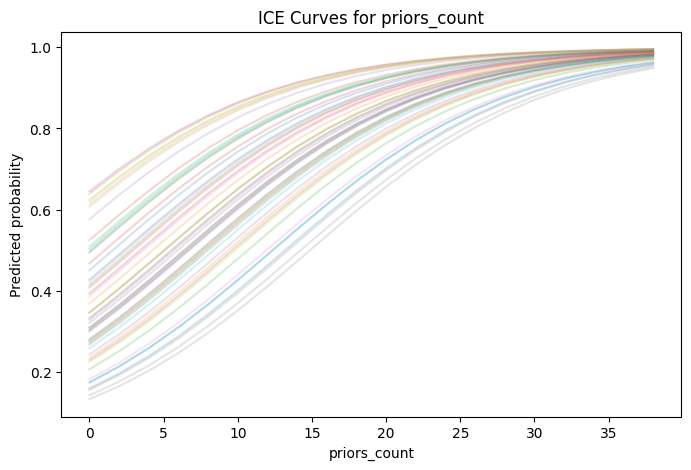

Average ICE range: 0.6215794247819114
Median ICE range: 0.6576439837441592


In [79]:
sample_idx = X_test.sample(50, random_state=42).index
x_sample = X_test.loc[sample_idx].copy()

grid = np.linspace(X_test['priors_count'].min(), X_test['priors_count'].max(), 20)

plt.figure(figsize=(8,5))

ice_ranges = []

for idx in x_sample.index:
    row = x_sample.loc[[idx]].copy()
    curve = []
    for g in grid:
        row_mod = row.copy()
        row_mod['priors_count'] = g
        prob = model.predict_proba(row_mod)[0, 1]
        curve.append(prob)
    ice_ranges.append(max(curve) - min(curve))
    plt.plot(grid, curve, alpha=0.2)

plt.xlabel('priors_count')
plt.ylabel('Predicted probability')
plt.title('ICE Curves for priors_count')
plt.show()

print("Average ICE range:", np.mean(ice_ranges))
print("Median ICE range:", np.median(ice_ranges))

The ICE curves show how predicted risk changes for individual observations as priors_count varies. If the curves move upward consistently, the model is treating prior offenses as a risk-increasing feature. The average and median ICE ranges summarize how sensitive predictions are across individuals. This helps evaluate robustness at the individual level, which is important because aggregate metrics can remain stable even when many individual predictions shift.

##Final summary
Overall, the model shows reasonably stable behavior across the checks performed in this audit. The gap between training and test performance is small, which suggests that the model is not heavily overfitting and can generalize to unseen data to some extent. The distribution drift analysis also indicates that the train and test datasets are fairly similar for the selected features, so there is no strong evidence of instability between the two samples.
At the same time, the robustness checks highlight an important limitation. Even though the overall accuracy remains unchanged under the stress test, a noticeable portion of individual predictions shifts when inputs are perturbed. This means that the model can appear stable at an aggregate level while still being sensitive at the individual level, which is something that should not be ignored.
The slice-based evaluation further reinforces this point. While performance looks similar across larger groups, there are differences in prediction rates and accuracy across subgroups. Some groups even show perfect performance, but this is likely due to small sample sizes rather than true model reliability. This suggests that relying only on overall metrics can hide important variation in how the model behaves across different populations.

In summary, the model works as a simple and interpretable baseline, but it is not yet strong enough for real-world deployment without further checks. In practice, it would be important to continue monitoring for distribution shifts, evaluate performance on larger and more balanced subgroups, and improve robustness so that predictions are less sensitive to small changes in inputs.